# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


**Dataset yang digunakan: UCI Heart Disease (Cleveland).**

Dataset ini berasal dari [UCI Machine Learning Repository - Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease). Dataset memuat **303 baris** dan **14 kolom** (13 fitur + 1 target) tanpa header, dengan pemisah koma. 

Urutan kolomnya: `age`, `sex`, `cp`, `trestbps`, `chol`, `fbs`, `restecg`, `thalach`, `exang`, `oldpeak`, `slope`, `ca`, `thal`, `target`.

Nilai yang hilang dikodekan sebagai token literal `"?"` (terutama pada kolom `ca` dan `thal`). Kolom `target` aslinya bernilai 0-4 (tingkat keparahan).

Untuk pengerjaan submission ini, target dibinarisasi menjadi **klasifikasi biner**: `0` = tidak ada penyakit, dan `1` = ada penyakit.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
.import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Lokasi direktori preprocessing
def _find_preprocessing_dir() -> Path:
    for candidate in (Path.cwd(), Path.cwd() / "preprocessing"):
        if (candidate / "heart-disease_raw.csv").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "tidak dapat menemukan direktori preprocessing yang berisi "
        "'heart-disease_raw.csv' (jalankan notebook dari folder preprocessing/)"
    )


PREPROCESSING_DIR = _find_preprocessing_dir()
RAW_PATH = PREPROCESSING_DIR / "heart-disease_raw.csv"
OUTPUT_PATH = PREPROCESSING_DIR / "heart-disease_preprocessing.csv"

# Impor transform bersama dari skrip otomasi agar output notebook dan skrip identik
_automate_path = PREPROCESSING_DIR / "automate_Raditya-Putra-Farma.py"
_spec = importlib.util.spec_from_file_location("automate_preprocessing", _automate_path)
automate = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(automate)

# Pakai kembali nama kolom, nama target, missing token, dan fungsi preprocessing.
COLUMN_NAMES = automate.COLUMN_NAMES
TARGET_COLUMN = automate.TARGET_COLUMN
MISSING_TOKEN = automate.MISSING_TOKEN
preprocess_dataset = automate.preprocess_dataset

print("Pandas            :", pd.__version__)
print("NumPy             :", np.__version__)
print("Direktori data    :", PREPROCESSING_DIR)
print("Nama kolom (14)   :", COLUMN_NAMES)
print("Kolom target      :", TARGET_COLUMN)
print("Token nilai hilang:", repr(MISSING_TOKEN))

Pandas            : 2.2.3
NumPy             : 2.2.6
Direktori data    : C:\Users\HP\Desktop\Semester 6\Dicoding x IBM Program Pijak\[Course] Membangun Sistem Machine Learning\preprocessing
Nama kolom (14)   : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Kolom target      : target
Token nilai hilang: '?'


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# ambil file mentah UCI Cleveland (tanpa header) dan tetapkan 14 nama kolom.
try:
    df_raw = pd.read_csv(RAW_PATH, header=None, names=COLUMN_NAMES)
except Exception as exc: 
    raise RuntimeError(
        f"dataset could not be loaded from {RAW_PATH!r}: {exc}"
    ) from exc

n_rows, n_cols = df_raw.shape
print(f"Dataset berhasil dimuat: {n_rows} baris x {n_cols} kolom")
df_raw.head()

Dataset berhasil dimuat: 303 baris x 14 kolom


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

**4.1 Struktur dan tipe data.** Periksa jumlah baris/kolom serta tipe data tiap fitur.

In [3]:
# Jumlah baris/kolom dan tipe data setiap fitur.
print(f"Jumlah baris : {df_raw.shape[0]}")
print(f"Jumlah kolom : {df_raw.shape[1]}")
print("\nTipe data per fitur (ca & thal bertipe object karena token '?'):")
df_raw.dtypes

Jumlah baris : 303
Jumlah kolom : 14

Tipe data per fitur (ca & thal bertipe object karena token '?'):


age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object

**4.2 Ringkasan statistik numerik** untuk tiap fitur.

In [4]:
# Ringkasan statistik numerik (count, mean, std, min, 25/50/75%, max).
# Token "?" diubah ke NaN dulu agar seluruh kolom dapat diringkas secara numerik.
numeric_view = df_raw.replace(MISSING_TOKEN, np.nan).apply(pd.to_numeric, errors="coerce")
numeric_view.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


**4.3 Pemeriksaan missing value** 

In [ ]:
missing_counts = df_raw.replace(MISSING_TOKEN, np.nan).isna().sum()
print("Jumlah nilai hilang per fitur (token '?' dihitung sebagai hilang):")
missing_counts

Jumlah nilai hilang per fitur (token '?' dihitung sebagai hilang):


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

**4.4 Visualisasi**: distribusi target dan korelasi antar fitur.

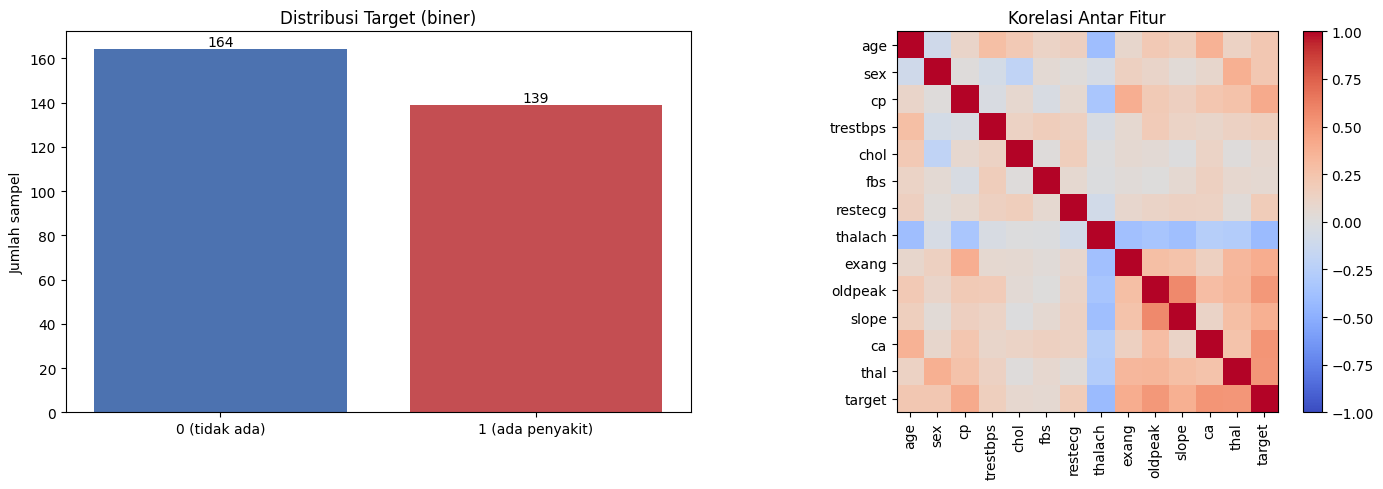

In [ ]:
# Visualisasi 1: distribusi kelas target (0 = tidak ada penyakit, 1 = ada penyakit).
# Visualisasi 2: heatmap korelasi antar fitur numerik.
target_binary = (numeric_view[TARGET_COLUMN].fillna(0) >= 1).astype(int)
target_counts = target_binary.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    ["0 (tidak ada)", "1 (ada penyakit)"],
    target_counts.values,
    color=["#4C72B0", "#C44E52"],
)
axes[0].set_title("Distribusi Target (biner)")
axes[0].set_ylabel("Jumlah sampel")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v, str(int(v)), ha="center", va="bottom")

corr = numeric_view.corr()
im = axes[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr.columns)))
axes[1].set_xticklabels(corr.columns, rotation=90)
axes[1].set_yticks(range(len(corr.columns)))
axes[1].set_yticklabels(corr.columns)
axes[1].set_title("Korelasi Antar Fitur")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

**Langkah 1: Menangani missing value.** 

Data mentah mengkodekan missing value sebagai token `"?"`. Saya ubah token tersebut menjadi `NaN` agar dapat ditangani secara numerik oleh pandas.

In [ ]:
# Salin data mentah dan ubah token "?" menjadi NaN.
df_proc = df_raw.copy()
df_proc = df_proc.replace(MISSING_TOKEN, np.nan)
print("Nilai hilang setelah '?' -> NaN:")
print(df_proc.isna().sum()[lambda s: s > 0])

Nilai hilang setelah '?' -> NaN:
ca      4
thal    2
dtype: int64


**Langkah 2: Koersi numerik.** Karena `"?"` membuat kolom `ca` dan `thal` bertipe object, seluruh kolom dikonversi ke tipe numerik, jadi nilai yang tidak valid menjadi `NaN`.

In [ ]:
# Konversi seluruh kolom menjadi tipe numerik. Disini nilai yang tidak dapat diparsing bakal menjadi NaN.
for col in df_proc.columns:
    df_proc[col] = pd.to_numeric(df_proc[col], errors="coerce")
df_proc.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

**Langkah 3: Binarisasi target.** 

Target asli bernilai 0-4. Karena ini kasus klasifikasi biner, maka nilai 0 tetap 0 (tidak ada penyakit) dan nilai 1-4 dipetakan menjadi 1 (ada penyakit).

In [ ]:
df_proc[TARGET_COLUMN] = (df_proc[TARGET_COLUMN].fillna(0) >= 1).astype(int)
df_proc[TARGET_COLUMN].value_counts()

target
0    164
1    139
Name: count, dtype: int64

**Langkah 4: Imputasi median.** 

Sisa nilai hilang pada fitur diisi dengan median kolom.

In [ ]:
# Pemilihan median karena median tahan terhadap outlier pada ca/thal).
feature_cols = [c for c in df_proc.columns if c != TARGET_COLUMN]
for col in feature_cols:
    median = df_proc[col].median()
    if pd.isna(median):
        median = 0.0
    df_proc[col] = df_proc[col].fillna(median)
print("Total nilai hilang setelah imputasi:", int(df_proc.isna().sum().sum()))

Total nilai hilang setelah imputasi: 0


**Langkah 5: Hapus duplikat.** 

In [ ]:
before = len(df_proc)
df_proc = df_proc.drop_duplicates().reset_index(drop=True)
after = len(df_proc)
print(f"Baris sebelum: {before}, sesudah hapus duplikat: {after}")

Baris sebelum: 303, sesudah hapus duplikat: 303


**Langkah 6: Verifikasi hasil.** 

In [ ]:
# Pastikan seluruh kolom numerik dan tidak ada nilai hilang.
df_proc = df_proc.apply(pd.to_numeric)
print("Jumlah nilai hilang :", int(df_proc.isna().sum().sum()))
all_numeric = bool(df_proc.dtypes.apply(pd.api.types.is_numeric_dtype).all())
print("Semua kolom numerik :", all_numeric)
df_proc.head()

Jumlah nilai hilang : 0
Semua kolom numerik : True


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


**Langkah 7: Konsistensi skrip & penyimpanan.** 

Gunakan transform bersama dari `automate_Raditya-Putra-Farma.py` untuk menghasilkan output kanonik, verifikasi identik dengan langkah manual di atas, lalu simpan ke `heart-disease_preprocessing.csv`.

In [ ]:
processed = preprocess_dataset(RAW_PATH, OUTPUT_PATH)

pd.testing.assert_frame_equal(
    df_proc.reset_index(drop=True), processed.reset_index(drop=True)
)
print("Notebook output identik dengan output skrip otomatis: OK")
print(f"Dataset hasil preprocessing disimpan ke: {OUTPUT_PATH}")
print(f"Bentuk akhir : {processed.shape[0]} baris x {processed.shape[1]} kolom")
print("Distribusi target:", processed[TARGET_COLUMN].value_counts().to_dict())
processed.head()

Notebook output identik dengan output skrip otomatis: OK
Dataset hasil preprocessing disimpan ke: C:\Users\HP\Desktop\Semester 6\Dicoding x IBM Program Pijak\[Course] Membangun Sistem Machine Learning\preprocessing\heart-disease_preprocessing.csv
Bentuk akhir : 303 baris x 14 kolom
Distribusi target: {0: 164, 1: 139}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
